# Assigment I: Profiling Codes

## Task 1.1

In order to measure the clock granularity of different timer we use the provided benchmark which we run a 1000 times.

In [1]:
import time
import timeit
import numpy as np

### time()

In [6]:
def checktick():
    M = 1000
    timesfound = np.empty(M)
    for i in range(M):
        t1 = time.time()  # get timestamp from timer
        t2 = time.time()  # get timestamp from timer
        while (t2 - t1) < 1e-16:  # if zero then we are below clock granularity, retake timing
            t2 = time.time()  # get timestamp from timer
        t1 = t2  # this is outside the loop
        timesfound[i] = t1  # record the time stamp
    Delta = np.diff(timesfound)  # it should be cast to int only when needed
    minDelta = Delta.min()
    return minDelta * 1e9


print(checktick(), "ns")

238.4185791015625 ns


### timeit()

In [5]:
def checktick():
    M = 1000
    timesfound = np.empty(M)
    for i in range(M):
        t1 = timeit.default_timer()  # get timestamp from timer
        t2 = timeit.default_timer()  # get timestamp from timer
        while (t2 - t1) < 1e-16:  # if zero then we are below clock granularity, retake timing
            t2 = timeit.default_timer()  # get timestamp from timer
        t1 = t2  # this is outside the loop
        timesfound[i] = t1  # record the time stamp
    Delta = np.diff(timesfound)  # it should be cast to int only when needed
    minDelta = Delta.min()
    return minDelta * 1e9


print(checktick(), "ns")

119.99873095192015 ns


### time_ns()

In [4]:
def checktick():
    M = 1000
    timesfound = np.empty(M, dtype='int')
    for i in range(M):
        t1 = time.time_ns()  # get timestamp from timer
        t2 = time.time_ns()  # get timestamp from timer
        while (t2 - t1) < 1e-16:  # if zero then we are below clock granularity, retake timing
            t2 = time.time_ns()  # get timestamp from timer
        t1 = t2  # this is outside the loop
        timesfound[i] = t1  # record the time stamp
    Delta = np.diff(timesfound)  # it should be cast to int only when needed
    minDelta = Delta.min()
    return minDelta


print(checktick(), "ns")

150 ns


As can be seen the precision on this machine is much better than the stated 1ms, with `timeit` having the best precision.

## Task 1.2

The decorator is based on the Lecture 1.5, with the added functionality of rerunning the function a certain amount of times.

In [1]:
import timeit
import JuliaSet
import numpy as np
from functools import wraps


def timerdec(fn):
    @wraps(fn)
    def measure(*args, **kwargs):
        M = 30
        dt = np.empty(M)
        result = None
        for i in range(M):
            t1 = timeit.default_timer()
            result = fn(*args, **kwargs)
            t2 = timeit.default_timer()
            dt[i] = t2 - t1
        print(f"@timedec: {fn.__name__} takes {dt.mean()} +/- {dt.std()} s (Based on {M} runs)\n")
        return result

    return measure

We wrap and test the function separately so they don't interfere with each other. This wrapping is equivalent to putting the `@timerdec` in the source code.

In [2]:
JuliaSet.calc_pure_python = timerdec(JuliaSet.calc_pure_python)
JuliaSet.calc_pure_python(desired_width=1000, max_iterations=300)

@timedec: calc_pure_python takes 2.9398750937000537 +/- 0.01779296150542568 s (Based on 30 runs)



In [2]:
JuliaSet.calculate_z_serial_purepython = timerdec(JuliaSet.calculate_z_serial_purepython)
JuliaSet.calc_pure_python(desired_width=1000, max_iterations=300)

@timedec: calculate_z_serial_purepython takes 2.750056852699587 +/- 0.016442060883714315 s (Based on 30 runs)



As can be seen the deviation is in 10s of milliseconds and is about 100x bigger that our clock granularity. Clock granularity affect mostly events that are shorter than it, but that has nothing to do with the spread of the runs, depending on the system the spread could be bigger or smaller.

## Task 1.3

Here we attempt to use Jupyter Notebook magic commands to profile, with a varying amount of success.

In [2]:
%load_ext line_profiler
import pstats
from JuliaSet import calc_pure_python, calculate_z_serial_purepython

In [8]:
%prun -D p.stats calc_pure_python(desired_width=1000, max_iterations=300)
# Equal to python3 -m cProfile -o p.stats JuliaSet.py

 
*** Profile stats marshalled to file 'p.stats'.


In [7]:
stats = pstats.Stats("p.stats")
stats.sort_stats("cumulative")
stats.print_stats()

Wed Jan 21 14:25:49 2026    p.stats

         36221987 function calls in 5.783 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    5.783    5.783 {built-in method builtins.exec}
        1    0.011    0.011    5.783    5.783 JuliaSet.py:1(<module>)
        1    0.355    0.355    5.772    5.772 JuliaSet.py:21(calc_pure_python)
        1    3.487    3.487    5.273    5.273 JuliaSet.py:60(calculate_z_serial_purepython)
 34219980    1.785    0.000    1.785    0.000 {built-in method builtins.abs}
  2002000    0.144    0.000    0.144    0.000 {method 'append' of 'list' objects}
        1    0.000    0.000    0.000    0.000 {method 'disable' of '_lsprof.Profiler' objects}
        2    0.000    0.000    0.000    0.000 {built-in method builtins.len}




In [4]:
#This displays the output of "python3 -m snakeviz p.stats --server"
from IPython.display import HTML, display
display(HTML(filename="cProfile.html"))

In [11]:
# Runs the line_profiler without having to place the `@profiler` tags
p = %lprun -f calc_pure_python -f calculate_z_serial_purepython -r calc_pure_python(desired_width=1000, max_iterations=300)
p.print_stats()

Timer unit: 1e-09 s

Total time: 42.9022 s
File: /home/pavel/IdeaProjects/DD2358/Ass1/JuliaSet.py
Function: calc_pure_python at line 20

Line #      Hits         Time  Per Hit   % Time  Line Contents
    20                                           def calc_pure_python(desired_width, max_iterations):
    21                                               """Create a list of complex coordinates (zs) and complex parameters (cs),
    22                                               build Julia set"""
    23         1       1670.0   1670.0      0.0      x_step = (x2 - x1) / desired_width
    24         1        720.0    720.0      0.0      y_step = (y1 - y2) / desired_width
    25         1        530.0    530.0      0.0      x = []
    26         1        530.0    530.0      0.0      y = []
    27         1        510.0    510.0      0.0      ycoord = y2
    28      1001     250640.0    250.4      0.0      while ycoord > y1:
    29      1000     252825.0    252.8      0.0          y.append(

From Task 1.2 we already know the average runtimes without the profilers. cProfile reported 5.8s total runtime which is ~2x increase, the line_profile reports a 42.9s and 29.24s runtimes for the two functions which are 14.6x and 10.6x slowdowns.

## Task 1.4

We reduce problem size from 1000 > 200 to save time.

In [1]:
%load_ext memory_profiler
from JuliaSet import calc_pure_python, calculate_z_serial_purepython

In [3]:
%mprun -f calc_pure_python -f calculate_z_serial_purepython calc_pure_python(desired_width=200, max_iterations=300)
#python3 -m memory_profiler JuliaSet.py > m.stats

In [5]:
%cat m.stats

Filename: JuliaSet.py

Line #    Mem usage    Increment  Occurrences   Line Contents
    20   49.062 MiB   49.062 MiB           1   @profile
    21                                         def calc_pure_python(desired_width, max_iterations):
    22                                             """Create a list of complex coordinates (zs) and complex parameters (cs),
    23                                             build Julia set"""
    24   49.062 MiB    0.000 MiB           1       x_step = (x2 - x1) / desired_width
    25   49.062 MiB    0.000 MiB           1       y_step = (y1 - y2) / desired_width
    26   49.066 MiB    0.004 MiB           1       x = []
    27   49.066 MiB    0.000 MiB           1       y = []
    28   49.066 MiB    0.000 MiB           1       ycoord = y2
    29   49.074 MiB    0.004 MiB         201       while ycoord > y1:
    30   49.074 MiB    0.004 MiB         200           y.append(ycoord)
    31   49.074 MiB    0.000 MiB         200           ycoord += y_step

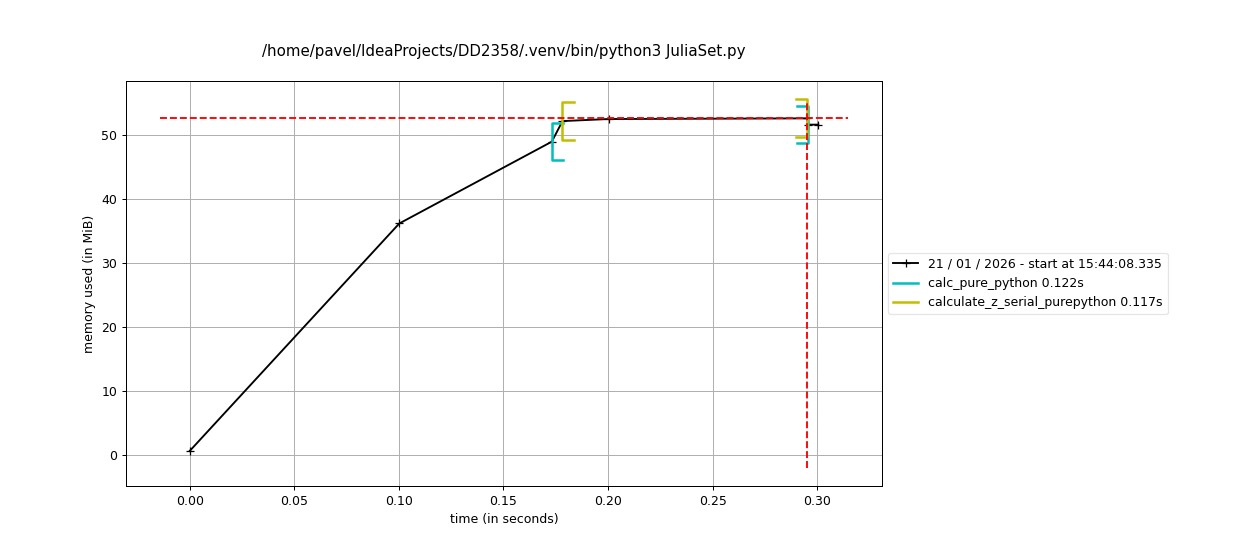

In [4]:
#python3 -m mprof plot mprofile_*.dat --output memory_plot.png
from IPython.display import Image
Image("memory_plot.png")

Redoing the benchmark from Task 1.2 on the reduced problem we get 116ms and 113ms for the 2 functions (which is the same as what `mprof` is showing), then using linux `time` we run the `memory_profiler` and `mprof` and get 105.1s and 0.6s of total runtime. Since `memory_profiler` uses `line_profiler` user the hood it tests the functions separately so the slowdown is 105.1/(0.116+0.113) = 450 which is enormous. For `mprof` we then have  0.6/0.116 = 5.2 which is barely noticeable.